In [1]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from tinygp import kernels, GaussianProcess
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer import SVI, Trace_ELBO, init_to_value, init_to_feasible, TraceEnum_ELBO
from numpyro.optim import Adam
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LogNorm

In [2]:
# Define the density function
def rho(x, y, z, e, p, q, rho0, s, a, b):
    eps = 1e-6
    #r = (jnp.abs(x)**2 + jnp.abs(y)**2 + jnp.abs(z)**2)**0.5
    m = ((jnp.abs(x)**(2 - e) + (jnp.abs(y) / (p))**(2 - e) + (jnp.abs(z) / (q))**(2 - e)))**(1 / (2 - e))
    den = rho0 / (((m+eps) / s)**a * (1 + ((m+eps) / s))**(b - a))
    return den / (p * q+eps)

#def simple(x,y,z,p):


# Define the model
def model(x, y, z, rho_obs=None):
    r = jnp.sqrt(x**2 + y**2 + z**2)#+1e-6

    # GP parameters for f_e (latent function for e)
    #sigma_e = numpyro.param("sigma_e", jnp.ones(()), constraint=dist.constraints.positive)
    #length_scale_e = numpyro.param("length_scale_e", jnp.ones(()), constraint=dist.constraints.positive)
    #kernel_e = sigma_e**2 * kernels.ExpSquared(length_scale_e)
    #gp_e = GaussianProcess(kernel_e, r, diag=1e-5, mean=0.0)
    #f_e = numpyro.sample("f_e", gp_e.numpyro_dist())
    #e = jnp.tanh(f_e)  # Constrain e to (-1, 1)
    
    # GP parameters for f_p (latent function for p)
    sigma_p = numpyro.param("sigma_p", jnp.ones(()), constraint=dist.constraints.positive)
    length_scale_p = numpyro.param("length_scale_p", jnp.ones(()), constraint=dist.constraints.positive)
    kernel_p = sigma_p**2 * kernels.ExpSquared(length_scale_p)
    gp_p = GaussianProcess(kernel_p, r, diag=1e-5, mean=0.0)
    f_p = numpyro.sample("f_p", gp_p.numpyro_dist())
    p = jax.nn.sigmoid(f_p)  # Constrain p to (0.1, 1)
    #p = 1-jnp.exp(-f_p)
   
    # GP parameters for f_q (latent function for q)
    #sigma_q = numpyro.param("sigma_q", jnp.ones(()), constraint=dist.constraints.positive)
    #length_scale_q = numpyro.param("length_scale_q", jnp.ones(()), constraint=dist.constraints.positive)
    #kernel_q = sigma_q**2 * kernels.ExpSquared(length_scale_q)
    #gp_q = GaussianProcess(kernel_q, r, diag=1e-5, mean=0.0)
    #f_q = numpyro.sample("f_q", gp_q.numpyro_dist())
    #q = 0.1 + 0.9 * jax.nn.sigmoid(f_q)  # Constrain q to (0.1, 1)

    # Constant parameters
    #p = numpyro.param("q", 0.7, constraint=dist.constraints.interval(0.1,1.0))
    q = numpyro.param("q", 0.6, constraint=dist.constraints.interval(0.1,1.0))
    e = numpyro.param("e", 0.0, constraint=dist.constraints.interval(-1.,1.))
    rho0 = numpyro.param("rho0", 1.0, constraint=dist.constraints.positive)
    s = numpyro.param("s", 1.0, constraint=dist.constraints.positive)
    a = numpyro.param("a", 1.0, constraint=dist.constraints.positive)
    b = numpyro.param("b", 2.0, constraint=dist.constraints.positive)

    

    

    # Add plate to handle batch dimension
    num_points = x.shape[0]  # assuming x, y, z are flat arrays
    with numpyro.plate("data", num_points):
        # Compute the density
        density = rho(x, y, z, e, p, q, rho0, s, a, b)
        
        # Observation model
        numpyro.sample("rho_obs", dist.Normal(density, 0.1), obs=rho_obs)


def custom_guide(x, y, z, rho_obs=None):
    # Define parameters for a multivariate normal distribution
    loc_f_p = numpyro.param("loc_f_p", jnp.zeros(x.shape[0]), constraint=dist.constraints.real)
    scale_tril_f_p = numpyro.param(
        "scale_tril_f_p",
        jnp.eye(x.shape[0]),  # Cholesky factor of covariance matrix
        constraint=dist.constraints.lower_cholesky,
    )
    
    # Use MultivariateNormal with learnable loc and scale_tril
    f_p = numpyro.sample("f_p", dist.MultivariateNormal(loc_f_p, scale_tril=scale_tril_f_p))
    



#guide = AutoNormal(model)

# Optimizer and inference
optim = Adam(1.)


svi = SVI(model, custom_guide, optim, TraceEnum_ELBO(10))


In [3]:
# Example usage
# Example input data (replace with actual data)
import jax.numpy as jnp

# Define the range for each coordinate
size = 3
ex = 1.0
x_range = jnp.linspace(-ex, ex, size)  
y_range = jnp.linspace(-ex, ex, size)
z_range = jnp.linspace(-ex, ex, size)

# Create a 3D grid
x, y, z = jnp.meshgrid(x_range, y_range, z_range, indexing="ij")
x_flat = x.flatten()
y_flat = y.flatten()
z_flat = z.flatten()
s_def = 1. 
e_def = 0.

def p_sigmoid(x,y,z):
    r = (jnp.abs(x)**2 + jnp.abs(y)**2 + jnp.abs(z)**2)**0.5
    p = jax.nn.sigmoid(r)
    return p, r

p_def , radius = p_sigmoid(x_flat,y_flat,z_flat)
q_def = 0.6
a_def = 2.
b_def = 4.
rho0_def = 1.
rho_obs = rho(x_flat, y_flat, z_flat, e_def, 0.7, q_def, rho0_def, s_def, a_def, b_def)

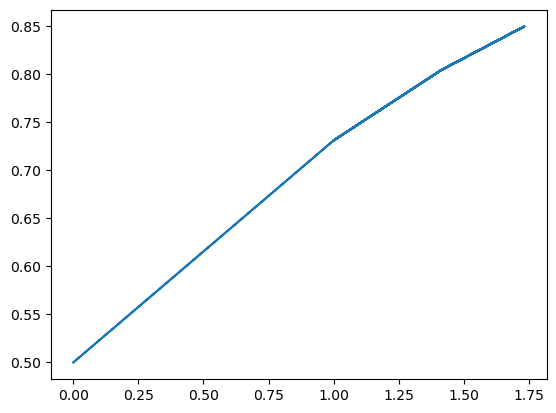

In [4]:
plt.plot(radius,p_def)

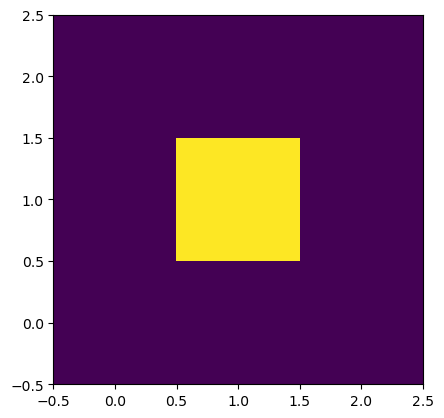

In [5]:
projection = jnp.sum(rho_obs.reshape(size,size,size), axis=2).T
plt.imshow(projection , origin='lower')

In [6]:
results = svi.run(jax.random.PRNGKey(42), 1000, x_flat, y_flat, z_flat, rho_obs=rho_obs)

100%|██████████| 1000/1000 [00:02<00:00, 448.09it/s, init loss: 283443464511328189065199616.0000, avg. loss [951-1000]: nan]


In [7]:
results.params

{'a': Array(nan, dtype=float32),
 'b': Array(nan, dtype=float32),
 'e': Array(nan, dtype=float32),
 'length_scale_p': Array(nan, dtype=float32),
 'loc_f_p': Array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan], dtype=float32),
 'q': Array(nan, dtype=float32),
 'rho0': Array(nan, dtype=float32),
 's': Array(nan, dtype=float32),
 'scale_tril_f_p': Array([[nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.],
        [nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.],
        [nan, nan, nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.],
        [nan, nan, nan, nan,  0.,  0.,  0.,  0.,  0.,  0., 